# Quran Translation — Exploratory Data Analysis

Analysis of the **English Saheeh International** translation (`translation_id=20`)
of the Quran, 6,236 verses across 114 chapters.

> **Scope note:** all findings describe an *English translation*, not the Arabic
> source text. Word counts, frequencies, and lengths are properties of the
> translation's prose.

Analysis logic lives in the reusable `quran_analysis` package; this notebook is a
thin presentation layer over `quran_analysis.eda` and `quran_analysis.text`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve repo root by walking up to the directory containing data/, so the
# notebook works whether launched from repo root or notebooks/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from quran_analysis import eda

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = eda.load_verses(ROOT / "data/processed/verses_translation_20.parquet")
df.shape

(6236, 27)

In [2]:
# Derived text columns:
#   clean_text       - footnotes/markup stripped, KEEPS [translator interpolations]
#   scripture_text   - interpolations removed (directly-rendered words only)
#   word_count / scripture_word_count - token counts for each variant
df[["verse_key", "clean_text", "scripture_text", "word_count", "scripture_word_count"]].head()

,verse_key,clean_text,scripture_text,word_count,scripture_word_count
0,1:1,"In the name of Allāh, the Entirely Merciful, t...","In the name of Allāh, the Entirely Merciful, t...",11,11
1,1:2,"All praise is due to Allāh, Lord of the worlds -","praise is to Allāh, Lord of the worlds -",10,8
2,1:3,"The Entirely Merciful, the Especially Merciful,","The Entirely Merciful, the Especially Merciful,",6,6
3,1:4,Sovereign of the Day of Recompense.,Sovereign of the Day of Recompense.,6,6
4,1:5,It is You we worship and You we ask for help.,It is You we worship and You we ask for help.,11,11


## Area 1 — Data Quality

Establish that the dataset is complete and understand its text-cleaning needs
before measuring anything.

In [3]:
# Headline integrity checks.
eda.data_quality_report(df)

total_verses                  6236
unique_chapters                114
null_translation                 0
empty_translation                0
duplicate_translation_text     126
verses_with_footnotes         1612
total_footnotes               1903
verses_with_brackets          3409
Name: data_quality, dtype: int64

In [4]:
# Verse counts per chapter vs the chapter metadata's expected count.
# An empty result below means every chapter has exactly the expected verses.
integrity = eda.verse_count_integrity(df)
mismatches = integrity.loc[~integrity["matches"]]
print(f"{len(mismatches)} / {len(integrity)} chapters mismatch expected verse counts")
mismatches

0 / 114 chapters mismatch expected verse counts


,chapter_id,chapter_name_simple,expected_verses,observed_verses,matches


In [5]:
# The 126 "duplicate" verse texts are legitimate refrains, not data errors.
# Ar-Rahman's recurring rhetorical question dominates.
eda.duplicate_examples(df).head(8)[["repeats", "verse_keys", "clean_text"]]

,repeats,verse_keys,clean_text
0,24,"[55:13, 55:16, 55:18, 55:21, 55:23, 55:25, 55:...",So which of the favors of your Lord would you ...
1,10,"[77:15, 77:19, 77:24, 77:28, 77:34, 77:37, 77:...","Woe, that Day, to the deniers."
2,8,"[26:9, 26:68, 26:104, 26:122, 26:140, 26:159, ...","And indeed, your Lord - He is the Exalted in M..."
3,7,"[55:38, 55:47, 55:57, 55:63, 55:71, 55:73, 55:75]",So which of the favors of your Lord would you ...
4,7,"[40:1, 41:1, 42:1, 43:1, 44:1, 45:1, 46:1]","Ḥā, Meem."
5,7,"[26:108, 26:126, 26:131, 26:144, 26:150, 26:16...",So fear Allāh and obey me.
6,6,"[26:8, 26:67, 26:103, 26:121, 26:174, 26:190]","Indeed in that is a sign, but most of them wer..."
7,6,"[2:1, 3:1, 29:1, 30:1, 31:1, 32:1]","Alif, Lām, Meem."


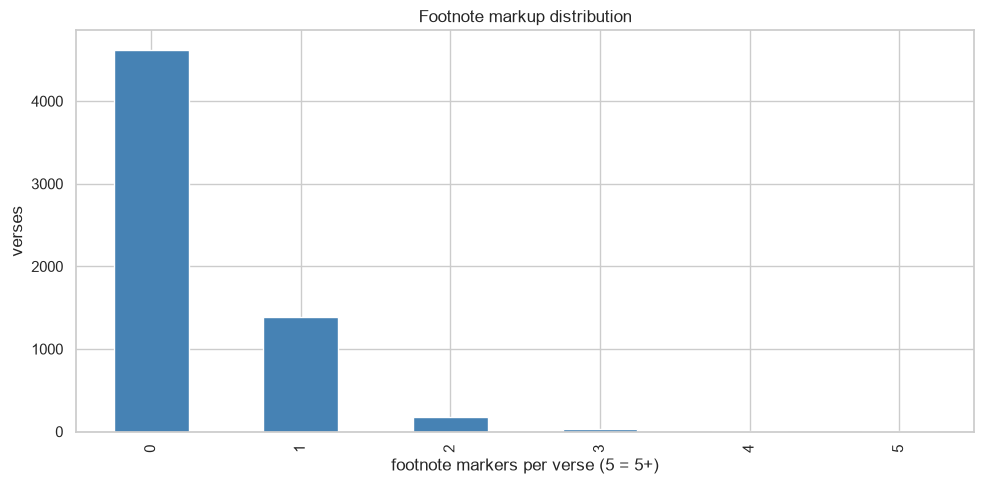

In [6]:
# Footnote markup coverage (now stripped from clean_text).
ax = (
    df["footnote_count"].clip(upper=5)
    .value_counts().sort_index()
    .plot(kind="bar", color="steelblue")
)
ax.set(xlabel="footnote markers per verse (5 = 5+)", ylabel="verses",
       title="Footnote markup distribution")
plt.tight_layout()

In [7]:
# Translator interpolations: 55% of verses contain [bracketed] clarifications,
# adding ~6.5% to the total word count. We keep both variants so each downstream
# analysis can choose its basis.
total = df["word_count"].sum()
scripture = df["scripture_word_count"].sum()
print(f"With interpolations : {total:,} words")
print(f"Scripture-only      : {scripture:,} words")
print(f"Interpolations add  : {total - scripture:,} words ({(total - scripture) / total:.1%})")

With interpolations : 159,867 words
Scripture-only      : 149,553 words
Interpolations add  : 10,314 words (6.5%)


**Area 1 takeaways**

- Dataset is **complete and clean**: 6,236 verses, 114 chapters, zero verse-count
  mismatches, no null/empty translations.
- Two cleaning concerns handled: `<sup>` footnote markup (1,612 verses) and
  `[bracketed]` translator interpolations (55% of verses, ~6.5% of words).
- "Duplicate" texts are real refrains (e.g. Ar-Rahman ×24), not errors.

## Area 2 — Structural Overview

### Thread A — Ordering: chronological vs canonical

The Quran's 114 chapters are **not** arranged in the order they were revealed.
Here we quantify how they *are* arranged, how far that departs from chronology,
and whether any alternate (e.g. ring/concentric) structure is detectable.

In [8]:
order = eda.ordering_table(df)   # chapter_id, revelation_order, verses, displacement, ...

# Q1: the book is arranged roughly longest-chapter-first.
rho = order["chapter_id"].corr(order["verses"], method="spearman")
print(f"Spearman(canonical position, chapter length) = {rho:.3f}  (strong 'longest-first')")
for lo, hi, lbl in [(1, 38, "first third"), (39, 76, "middle third"), (77, 114, "last third")]:
    seg = order[order.chapter_id.between(lo, hi)]
    print(f"  {lbl:13s} (ch {lo:>3}-{hi:<3}): median {seg.verses.median():5.1f} verses")

Spearman(canonical position, chapter length) = -0.845  (strong 'longest-first')
  first third   (ch   1-38 ): median  98.5 verses
  middle third  (ch  39-76 ): median  37.5 verses
  last third    (ch  77-114): median  11.0 verses


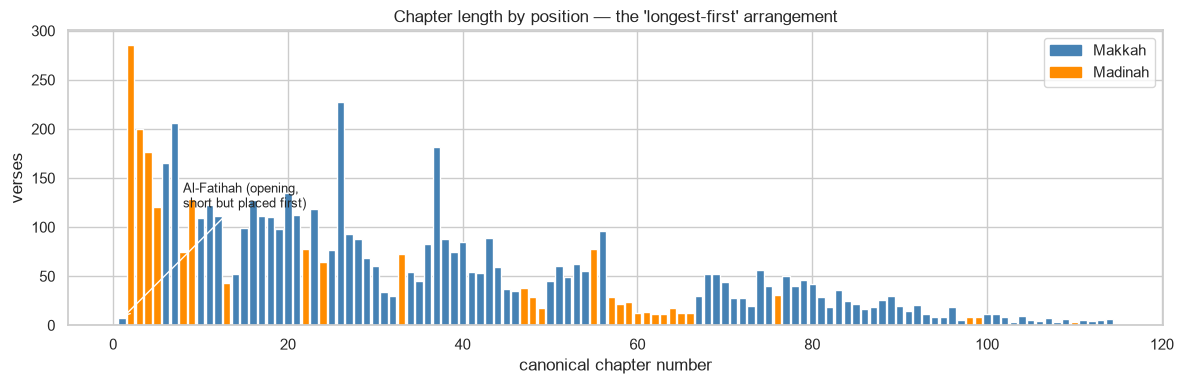

In [9]:
# Q1 visual: chapter length by canonical position, with the longest-first trend.
fig, ax = plt.subplots(figsize=(12, 4))
colors = order["revelation_place"].map({"makkah": "steelblue", "madinah": "darkorange"})
ax.bar(order["chapter_id"], order["verses"], color=colors, width=0.85)
ax.set(xlabel="canonical chapter number", ylabel="verses",
       title="Chapter length by position — the 'longest-first' arrangement")
ax.annotate("Al-Fatihah (opening,\nshort but placed first)", xy=(1, 7), xytext=(8, 120),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Makkah"), Patch(color="darkorange", label="Madinah")])
plt.tight_layout()

In [10]:
# Q2: displacement between revelation order and canonical position.
# Largest movers are Madinan chapters revealed late but placed near the front.
movers = order.reindex(order["displacement"].abs().sort_values(ascending=False).index).head(6)
print(movers[["chapter_id", "name", "revelation_place", "revelation_order", "displacement", "verses"]].to_string(index=False))
print()
print("Mean signed displacement by revelation place:")
print(order.groupby("revelation_place", observed=True)["displacement"].mean().round(1).to_string())

 chapter_id       name revelation_place  revelation_order  displacement  verses
          5 Al-Ma'idah          madinah               112           107     120
        111   Al-Masad           makkah                 6          -105       5
          9  At-Tawbah          madinah               113           104     129
         96   Al-'Alaq           makkah                 1           -95      19
        114     An-Nas           makkah                21           -93       6
        108 Al-Kawthar           makkah                15           -93       3

Mean signed displacement by revelation place:
revelation_place
madinah    53.4
makkah    -17.4


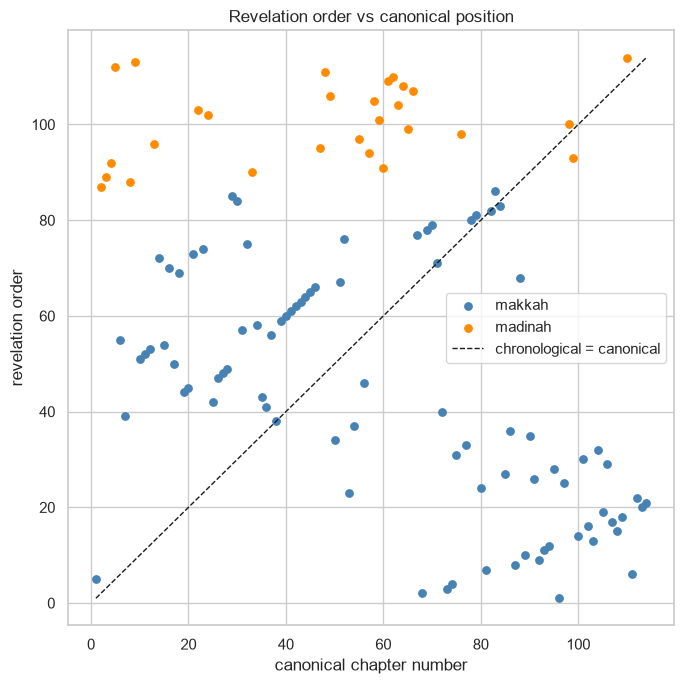

In [11]:
# Q2 visual: revelation order vs canonical position. Distance from the diagonal
# is the displacement; Madinan chapters sit far above it (revealed late, placed early).
fig, ax = plt.subplots(figsize=(7, 7))
for place, c in [("makkah", "steelblue"), ("madinah", "darkorange")]:
    s = order[order.revelation_place == place]
    ax.scatter(s["chapter_id"], s["revelation_order"], c=c, label=place, s=28)
ax.plot([1, 114], [1, 114], "k--", lw=1, label="chronological = canonical")
ax.set(xlabel="canonical chapter number", ylabel="revelation order",
       title="Revelation order vs canonical position")
ax.legend()
plt.tight_layout()

In [12]:
# Q3 (data caveat): in this dataset revelation_order does NOT interleave Makkah/Madinah.
mak = order[order.revelation_place == "makkah"]["revelation_order"]
mad = order[order.revelation_place == "madinah"]["revelation_order"]
print(f"Makkah revelation orders: {mak.min()}-{mak.max()}")
print(f"Madinah revelation orders: {mad.min()}-{mad.max()}")
print("=> all Makkan chapters precede all Madinan ones: revelation_order is a COARSE")
print("   traditional sequence (place-grouped), not a fine verse-level chronology.")

Makkah revelation orders: 1-86
Madinah revelation orders: 87-114
=> all Makkan chapters precede all Madinan ones: revelation_order is a COARSE
   traditional sequence (place-grouped), not a fine verse-level chronology.


In [13]:
# Q4: chronology is partly preserved locally in the canonical order.
seq = order["revelation_order"].to_numpy()
import numpy as np
lag1 = np.corrcoef(seq[:-1], seq[1:])[0, 1]
print(f"lag-1 autocorrelation of revelation order along canonical sequence = {lag1:.3f}")
print("Makkah/Madinah run-clustering:", eda.place_runs(df))
print("(far fewer runs than the random expectation => same-origin chapters cluster)")

lag-1 autocorrelation of revelation order along canonical sequence = 0.437
Makkah/Madinah run-clustering: {'observed_runs': 25, 'expected_runs_if_random': 43.2}
(far fewer runs than the random expectation => same-origin chapters cluster)


### Alternate structures — ring / concentric composition

Scholars (e.g. Farrin; Cuypers' *Semitic rhetoric*) argue some chapters are
arranged as **rings** — section A mirrors section A′ around a thematic center.
We test this on **Al-Baqarah** (the classic example) using *motif profiles*: each
section is scored over curated theme lexicons, and we check whether mirror-position
sections are more alike than a shuffled null allows.

> Caveat: this operates on the **English translation** and coarse sections. Ring
> arguments rest on Arabic verbal echoes and human-identified motifs, so a null
> here is **not** a refutation — only evidence that the pattern isn't detectable
> by these surface methods.

In [14]:
from quran_analysis import themes

baqarah = df[df.chapter_id == 2]
rukus = baqarah.groupby("ruku_number")["clean_text"].apply(" ".join).tolist()
nine = [" ".join(g) for g in np.array_split(baqarah["clean_text"].tolist(), 9)]

for label, units in [("40 ruku units", rukus), ("9 equal sections", nine)]:
    res = eda.ring_test(themes.motif_profiles(units))
    print(f"{label:18s}: mirror={res['mirror_similarity']:.3f}  "
          f"null={res['null_mean']:.3f}  z={res['z']:+.2f}  p={res['p_value']:.3f}")
print()
print("z ~ 0 and p ~ 0.5 at both granularities => no detectable concentric symmetry.")

40 ruku units     : mirror=0.375  null=0.402  z=-0.69  p=0.741


9 equal sections  : mirror=0.619  null=0.638  z=-0.36  p=0.611

z ~ 0 and p ~ 0.5 at both granularities => no detectable concentric symmetry.


**Thread A takeaways**

- **Arrangement is by length, not chronology**: Spearman(position, length) = −0.85;
  median chapter length falls 98.5 → 37.5 → 11 verses across the three thirds.
  Al-Fatihah is the deliberate short-but-first exception (the opening).
- **The big order-shifts are systematically Madinan** — Al-Ma'idah (+107) and
  At-Tawbah (+104) were revealed last but placed near the front.
- **Data caveat**: `revelation_order` here is place-grouped (all Makkan 1–86,
  all Madinan 87–114), so treat it as a coarse sequence, not a fine timeline.
- **Local chronology survives** in the canonical order (lag-1 autocorr 0.44;
  25 origin-runs vs ~43 expected) — same-origin chapters cluster.
- **Ring structure**: not detectable in Al-Baqarah via motif profiles on the
  English translation (z ≈ 0). A fair test of the scholarly claim needs Arabic
  roots / verbal-echo tracking.

### Thread B — Makkah vs Madinah profile

A popular characterization is that "Madinan chapters are longer." The data tells
a more precise story: the contrast is driven by **verse length**, not chapter
length, and the downstream density metrics all follow from that.

In [15]:
# One-glance profile. Note: similar words/page across places, but Madinan verses
# are ~3x longer, so Madinan pages hold fewer (longer) verses.
eda.place_profile(df)

,revelation_place,chapters,median_verses_per_chapter,median_words_per_verse,median_verses_per_page,median_words_per_page,median_verses_per_ruku
0,madinah,28,29.0,36.4,6.0,241.0,7.4
1,makkah,86,43.0,12.1,10.2,219.0,12.8


In [16]:
# Q5: chapter verse-counts are NOT significantly different by place.
from scipy.stats import mannwhitneyu

mak = order[order.revelation_place == "makkah"]["verses"]
mad = order[order.revelation_place == "madinah"]["verses"]
u, p = mannwhitneyu(mak, mad)
print(f"verses/chapter  -  Makkah median {mak.median():.0f}, Madinah median {mad.median():.0f}")
print(f"Mann-Whitney U p = {p:.3f}  ->  no significant difference in chapter length")
print("(Madinan chapters are bimodal: a few giants + many short ones.)")

verses/chapter  -  Makkah median 43, Madinah median 29
Mann-Whitney U p = 0.710  ->  no significant difference in chapter length
(Madinan chapters are bimodal: a few giants + many short ones.)


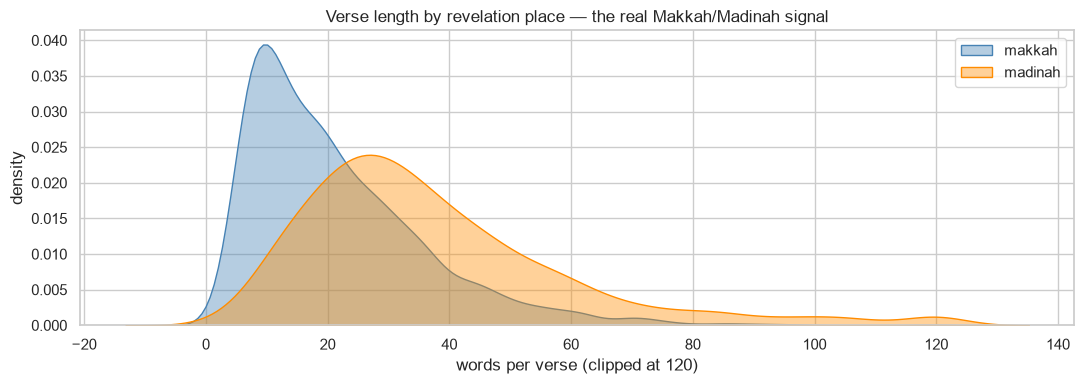

In [17]:
# Q6: but verse length DOES differ, systemically. Plot the word-per-verse
# distributions; Madinan mass sits well to the right.
fig, ax = plt.subplots(figsize=(11, 4))
for place, c in [("makkah", "steelblue"), ("madinah", "darkorange")]:
    sns.kdeplot(df[df.revelation_place == place]["word_count"].clip(upper=120),
                ax=ax, fill=True, alpha=0.4, color=c, label=place)
ax.set(xlabel="words per verse (clipped at 120)", ylabel="density",
       title="Verse length by revelation place — the real Makkah/Madinah signal")
ax.legend()
plt.tight_layout()

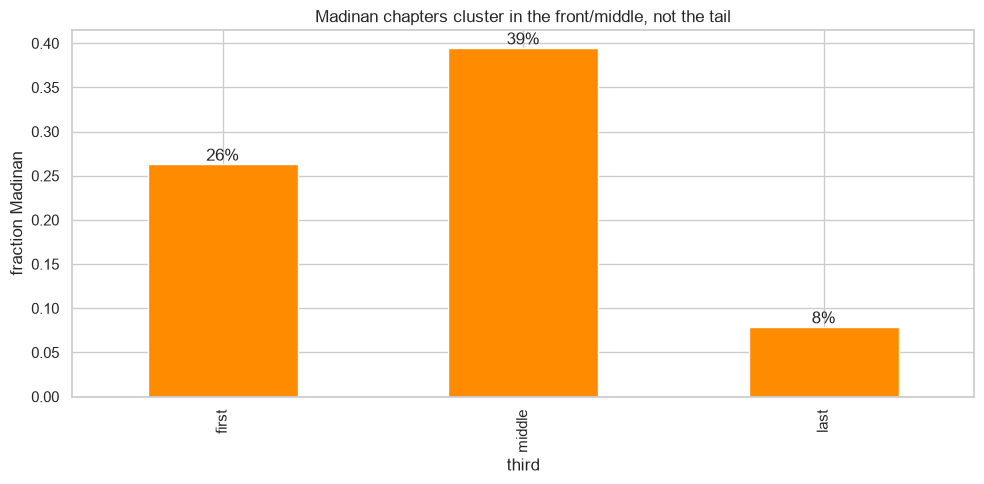

In [18]:
# Q7: where Madinan chapters sit in the book (share Madinan by canonical third).
thirds = pd.cut(order["chapter_id"], [0, 38, 76, 114], labels=["first", "middle", "last"])
share = order.assign(third=thirds).groupby("third", observed=True)["revelation_place"].apply(
    lambda s: (s == "madinah").mean()
)
ax = share.plot(kind="bar", color="darkorange")
ax.set(ylabel="fraction Madinan", title="Madinan chapters cluster in the front/middle, not the tail")
ax.bar_label(ax.containers[0], fmt="%.0f%%", labels=[f"{v:.0%}" for v in share])
plt.tight_layout()

**Thread B takeaways**

- **It's verse length, not chapter length.** Chapter verse-counts don't differ
  significantly by place (Mann-Whitney p ≈ 0.71); Madinan *verses* are ~2–3×
  longer (median 36 vs 12 words/verse), systemically.
- **Density follows from verse length**: Madinan pages hold fewer verses
  (6 vs 10) but roughly equal words (~240 vs ~220) — a near-constant page word
  budget, echoing the equal-length juz finding.
- **Placement**: Madinan chapters concentrate in the front/middle thirds and are
  nearly absent (8%) from the short-Makkan tail — a consequence of the
  longest-first ordering meeting their bimodal sizes.

## Area 3 — Text Length

Verse length is heavily right-skewed (median 21 words, max 258). Here we examine
the extremes, decompose what makes a *chapter* long, and ask whether length has
any structural pattern across the book or within a chapter.

In [19]:
# Q2: the longest verses are overwhelmingly Madinan legislative passages.
ext = eda.length_extremes(df, n=8)
print("LONGEST verses:")
print(ext["longest"][["verse_key", "chapter_name_simple", "word_count"]].to_string(index=False))
top50_madinan = (df.nlargest(50, "word_count")["revelation_place"] == "madinah").mean()
print(f"\n{top50_madinan:.0%} of the 50 longest verses are Madinan")

LONGEST verses:
verse_key chapter_name_simple  word_count
    2:282          Al-Baqarah         258
    73:20        Al-Muzzammil         163
    2:196          Al-Baqarah         151
      5:3          Al-Ma'idah         145
     4:11             An-Nisa         143
     4:12             An-Nisa         143
    5:110          Al-Ma'idah         143
    3:154          Ali 'Imran         141

96% of the 50 longest verses are Madinan


In [20]:
# Q2: the short tail is the muqatta'at (disjointed-letter chapter openers).
muqattaat = df[(df.verse_number == 1) & (df.word_count <= 5) & (df.clean_text.str.len() < 18)]
print(f"{len(muqattaat)} disjointed-letter opener verses, e.g.:")
print(muqattaat[["verse_key", "chapter_name_simple", "clean_text"]].head(6).to_string(index=False))

21 disjointed-letter opener verses, e.g.:
verse_key chapter_name_simple       clean_text
      2:1          Al-Baqarah Alif, Lām, Meem.
      3:1          Ali 'Imran Alif, Lām, Meem.
     20:1                Taha          Ṭā, Hā.
     26:1         Ash-Shu'ara  Ṭā, Seen, Meem.
     28:1            Al-Qasas  Ṭā, Seen, Meem.
     29:1         Al-'Ankabut Alif, Lām, Meem.


In [21]:
# Q3: decompose chapter length. log(total words) = log(verse count) + log(words/verse).
# Variance attribution shows verse-COUNT dominates, and the two factors reinforce.
cs = eda.chapter_summary(df).set_index("chapter_id")
lt, ln, lm = np.log(cs.total_words), np.log(cs.verses), np.log(cs.mean_words_per_verse)
print(f"var(log total words)   = {lt.var():.3f}")
print(f"  verse-count share    = {ln.var() / lt.var():.0%}  (+ covariance)")
print(f"  verse-length share   = {lm.var() / lt.var():.0%}  (+ covariance)")
print(f"  corr(log count, log length) = {np.corrcoef(ln, lm)[0, 1]:+.3f}  (factors reinforce)")

var(log total words)   = 2.258
  verse-count share    = 54%  (+ covariance)
  verse-length share   = 18%  (+ covariance)
  corr(log count, log length) = +0.469  (factors reinforce)


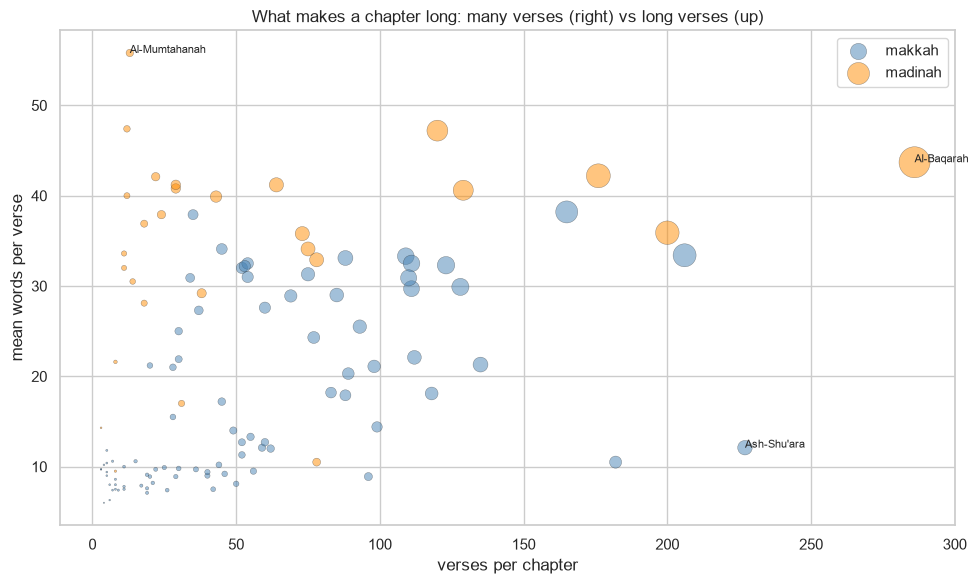

In [22]:
# Q3 visual: every chapter as verse-count vs words-per-verse (bubble = total words).
fig, ax = plt.subplots(figsize=(10, 6))
for place, c in [("makkah", "steelblue"), ("madinah", "darkorange")]:
    s = cs[cs.revelation_place == place]
    ax.scatter(s.verses, s.mean_words_per_verse, s=s.total_words / 25,
               alpha=0.5, color=c, label=place, edgecolor="k", linewidth=0.3)
for cid, lbl in [(2, "Al-Baqarah"), (26, "Ash-Shu'ara"), (60, "Al-Mumtahanah")]:
    ax.annotate(lbl, (cs.loc[cid, "verses"], cs.loc[cid, "mean_words_per_verse"]), fontsize=8)
ax.set(xlabel="verses per chapter", ylabel="mean words per verse",
       title="What makes a chapter long: many verses (right) vs long verses (up)")
ax.legend()
plt.tight_layout()

corr(within-chapter position, verse length) = +0.045  (negligible)
mean verse length: juz 1 = 34.9 words  ->  juz 30 = 9.0 words


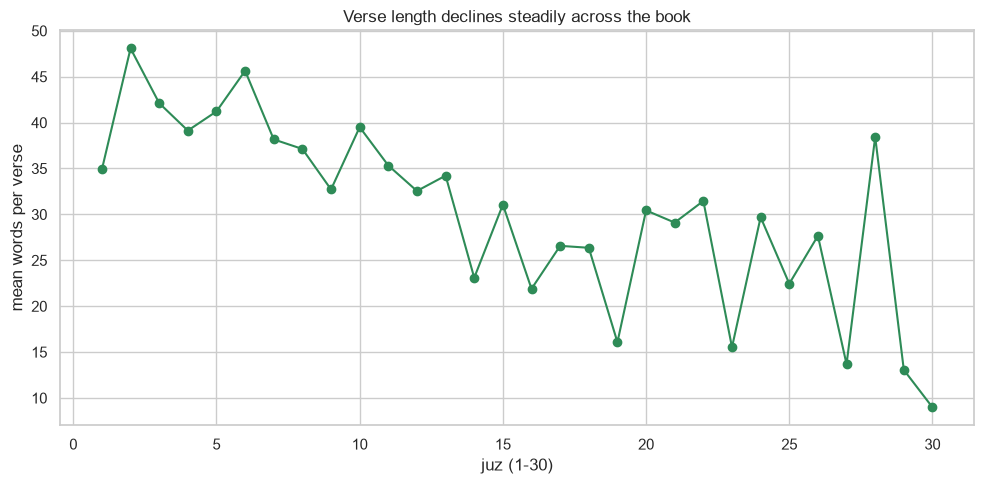

In [23]:
# Q4: within-chapter position has ~no effect, but length declines steadily
# across the book (juz 1 -> 30) under the longest-first arrangement.
rel_pos = df.groupby("chapter_id")["verse_number"].transform(lambda s: (s - 1) / max(len(s) - 1, 1))
print(f"corr(within-chapter position, verse length) = {rel_pos.corr(df.word_count):+.3f}  (negligible)")

juz_len = df.groupby("juz_number")["word_count"].mean()
print(f"mean verse length: juz 1 = {juz_len[1]:.1f} words  ->  juz 30 = {juz_len[30]:.1f} words")
ax = juz_len.plot(marker="o", color="seagreen")
ax.set(xlabel="juz (1-30)", ylabel="mean words per verse",
       title="Verse length declines steadily across the book")
plt.tight_layout()

**Area 3 takeaways**

- **Long verses are Madinan & legislative** — 2:282 (the debt verse, 258 words)
  leads; 96% of the 50 longest verses are Madinan. The short tail is the 21
  *muqaṭṭaʿāt* openers.
- **Chapter length is driven more by verse-count than verse-length** (54% vs 18%
  of log-variance), and the two reinforce (corr +0.47).
- **No within-chapter length pattern** (corr 0.04), but a **strong across-book
  decline** (juz 1: 35 words/verse → juz 30: 9; corr −0.76) — the verse-length
  shadow of the longest-first ordering.

## Area 4 — Word Frequency / Lexical

Word-frequency structure, each chapter's signature vocabulary, and a careful
(size-matched) look at lexical diversity.

Top tokens: ['and', 'the', 'you', 'of', 'is', 'to', 'they', 'allah']


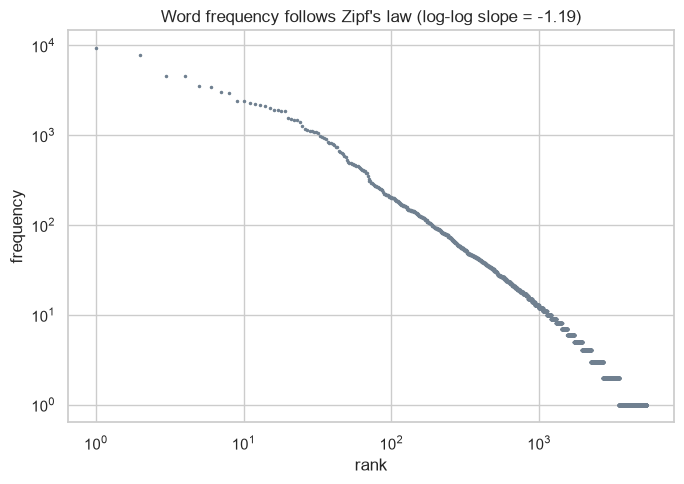

In [24]:
# Q1: frequency follows Zipf's law. Plot rank vs frequency on log-log and fit a
# slope over the first 1000 ranks (ideal Zipf slope = -1).
freqs = eda.word_frequencies(df, drop_stopwords=False)
rank = np.arange(1, len(freqs) + 1)
slope = np.polyfit(np.log(rank[:1000]), np.log(freqs.values[:1000]), 1)[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(rank, freqs.values, ".", ms=3, color="slategray")
ax.set(xlabel="rank", ylabel="frequency",
       title=f"Word frequency follows Zipf's law (log-log slope = {slope:.2f})")
plt.tight_layout()
print("Top tokens:", list(freqs.head(8).index))

In [25]:
# Q3: each chapter's signature terms via TF-IDF across all 114 chapters.
# These track each chapter's narrative/theme remarkably well.
sig = eda.chapter_signature_terms(df, top_n=5)
sig[sig.chapter_id.isin([1, 2, 12, 18, 19, 55, 112, 114])]

,chapter_id,name,signature_terms
0,1,Al-Fatihah,"especially, entirely, merciful, path, sovereign"
1,2,Al-Baqarah,"hajj, recall, acceptable, relations, write"
11,12,Yusuf,"joseph, prison, king, interpretation, master"
17,18,Al-Kahf,"cave, dhul, dog, youths, patience"
18,19,Maryam,"boy, zechariah, father, dutiful, alive"
54,55,Ar-Rahman,"favors, deny, balance, untouched, pass"
111,112,Al-Ikhlas,"eternal, born, equivalent, refuge, say"
113,114,An-Nas,"mankind, whispers, retreating, sovereign, evil"


In [26]:
# Q4: vocabulary richness, corrected for sample size.
# Raw TTR makes the smaller (Madinah) corpus look richer; matching sample sizes
# shows the two are essentially identical.
from quran_analysis import text as qtext

rich = eda.vocabulary_richness(df)
print(rich.to_string(index=False))
print()
raw = {}
for p in ["makkah", "madinah"]:
    toks = [t for txt in df[df.revelation_place == p].translation_text
            for t in qtext.tokenize(txt, drop_stopwords=True)]
    raw[p] = len(set(toks)) / len(toks)
print(f"(raw, sample-biased TTR:  makkah {raw['makkah']:.3f}  madinah {raw['madinah']:.3f})")

  group  total_content_tokens  matched_sample  ttr_matched  hapax_rate_matched
 makkah                 32056           19600       0.1667              0.4259
madinah                 19600           19600       0.1642              0.4212

(raw, sample-biased TTR:  makkah 0.124  madinah 0.164)


**Area 4 takeaways**

- **Zipfian frequencies** — log-log rank/frequency slope ≈ −1.2, typical of
  natural-language text.
- **Per-chapter TF-IDF recovers each chapter's subject** (Yusuf→prison/king,
  Ar-Rahman→favors/balance, An-Nas→mankind/whispers) — a clean, interpretable
  signature.
- **No real lexical-diversity gap by revelation place.** A size-matched TTR
  (~0.165 for both) shows the apparent Madinan "richness" was purely a
  sample-size artifact of raw TTR.

## Thread C — Major Themes (curated lexicons)

Themes are defined as **curated keyword lexicons** (`quran_analysis.themes`) — 12
themes from belief and afterlife to law, fighting, and charity. This is
interpretable (we choose the categories) and reproducible. Matching is by word
*prefix* so "believ" catches believe/believed/believers.

> Method note: a naïve **per-verse** theme rate is confounded by verse length —
> long Madinan verses collect more keyword hits regardless of topic. We therefore
> measure **intensity = hits per 1,000 words**.

47% of verses match no theme (narrative/connective text)


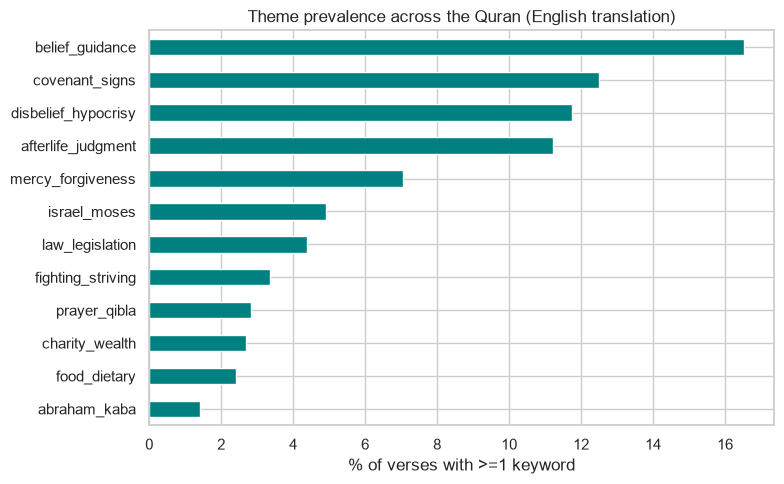

In [27]:
from quran_analysis import themes

# Overall prevalence: share of verses touching each theme at least once.
scores = themes.score_frame(df["translation_text"])
prevalence = (scores > 0).mean().sort_values(ascending=False)
ax = prevalence.mul(100).plot(kind="barh", color="teal", figsize=(8, 5))
ax.invert_yaxis()
ax.set(xlabel="% of verses with >=1 keyword", title="Theme prevalence across the Quran (English translation)")
plt.tight_layout()
print(f"{(scores.sum(1) == 0).mean():.0%} of verses match no theme (narrative/connective text)")

In [28]:
# Length-controlled Makkah vs Madinah theme intensity. Lift > 1 = more Madinan.
intensity = eda.theme_intensity(df)
intensity

,theme,madinah,makkah,lift
0,fighting_striving,3.52,0.87,4.05
1,charity_wealth,2.37,0.63,3.76
2,law_legislation,3.96,1.26,3.14
3,abraham_kaba,1.05,0.49,2.14
4,prayer_qibla,3.03,1.50,2.02
5,belief_guidance,11.30,7.01,1.61
6,disbelief_hypocrisy,6.23,4.73,1.32
7,covenant_signs,6.74,5.29,1.27
8,mercy_forgiveness,5.63,4.52,1.25
9,food_dietary,1.06,1.16,0.91


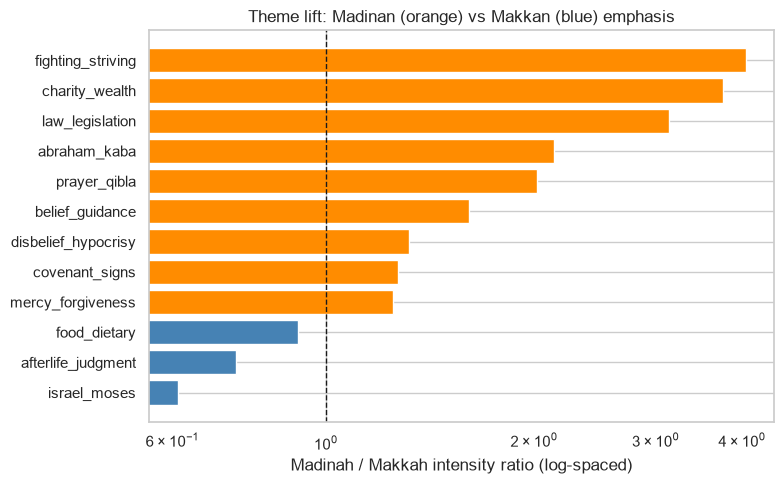

In [29]:
# Visualize the split: martial/legal/charity themes are strongly Madinan;
# eschatology and prophetic narratives lean Makkan (lift < 1).
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["darkorange" if v > 1 else "steelblue" for v in intensity["lift"]]
ax.barh(intensity["theme"], intensity["lift"], color=colors)
ax.axvline(1, color="k", lw=1, ls="--")
ax.invert_yaxis()
ax.set(xlabel="Madinah / Makkah intensity ratio (log-spaced)", xscale="log",
       title="Theme lift: Madinan (orange) vs Makkan (blue) emphasis")
plt.tight_layout()

In [30]:
# Representative verses (most keyword hits, excluding very short verses).
for theme in ["law_legislation", "fighting_striving", "afterlife_judgment", "israel_moses"]:
    rep = eda.representative_verses(df, theme, n=1).iloc[0]
    print(f"[{theme}]  {rep.verse_key} ({rep.hits} hits)")
    print(f"   {rep.clean_text[:110]}...\n")

[law_legislation]  2:282 (10 hits)
   O you who have believed, when you contract a debt for a specified term, write it down. And let a scribe write ...



[fighting_striving]  2:191 (8 hits)
   And kill them in battle wherever you overtake them and expel them from wherever they have expelled you, and fi...



[afterlife_judgment]  24:11 (4 hits)
   Indeed, those who came with falsehood are a group among you. Do not think it bad for you; rather, it is good f...



[israel_moses]  3:93 (4 hits)
   All food was lawful to the Children of Israel except what Israel , Jacob had made unlawful to himself before t...



**Thread C takeaways**

- **Belief/guidance is the most pervasive theme** (~16% of verses); ~47% of verses
  match no lexicon (narrative and connective text).
- **The Makkah/Madinah thematic split matches classical scholarship** — but only
  after controlling for verse length. Madinan revelation is far more about
  **fighting (4×), charity (3.8×), law (3.1×), and prayer/qibla (2×)**; Makkan
  revelation leans toward **eschatology (afterlife 0.74×) and prophetic
  narratives (Israel/Moses 0.61×)**.
- The naïve per-verse rate hid this (every theme looked "Madinan") — a reminder
  that verse-length normalization is essential for any per-verse text metric here.